# MTSamples: sampling-focused EDA and 50-report source subset

Purpose: inspect the local dataset, form a usable candidate pool, and reproducibly propose **50 diverse source reports** for FaithfulMed's shared baseline/evaluation set. The transcription is the clinical source document. This notebook does not simplify reports, generate model outputs, or create clinical/gold annotations.

The active selection is **v3-medium-with-allergy-exceptions-proposed: 48 medium-length reports plus two documented Allergy/Immunology length exceptions, awaiting team review and freezing**. The original mixed-length analysis remains below as historical work; the new medium-length analysis is appended after its summary. Only the medium-focused set is exported to `data/curated_baseline/`. It is a selected evaluation subset, not a cleaned replacement for all MTSamples. MedAESQA remains the separate Verifier calibration dataset.

Run all cells from the repository root or `EDAs/`. The existing project environment has pandas, NumPy, matplotlib, scikit-learn, and openpyxl. Cleaning and selection functions are shared with `EDAs/mtsamples_sampling.py` to avoid two implementations drifting apart. EDA calculations and plots appear below. Running this notebook recomputes the selection in memory without overwriting the exports.


In [1]:
from pathlib import Path
from collections import Counter
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "EDAs/mtsamples_sampling.py").exists())
if str(ROOT / "EDAs") not in sys.path:
    sys.path.insert(0, str(ROOT / "EDAs"))
from mtsamples_sampling import (
    RANDOM_SEED, MIN_WORDS, NEAR_DUPLICATE_JACCARD,
    SPECIALTY_TARGETS, LENGTH_TARGETS, CONTENT_PATTERNS,
    load_source, blank_mask, normalize_text, word_counts,
    clean_candidates, select_reports, validate_selection, content_indicators,
)

SOURCE = ROOT / "data/mtsamples.csv"  # Can also be an .xlsx/.xlsm file.
source_hash_before = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
raw = load_source(SOURCE)  # keep_default_na=False preserves empty fields and text.
print(f"Source: {SOURCE.name}; shape: {raw.shape}; random seed: {RANDOM_SEED}")
print("Columns:", raw.columns.tolist())
print("Source SHA-256:", source_hash_before)
display(raw.drop(columns="transcription").head())


Source: mtsamples.csv; shape: (4999, 6); random seed: 42
Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
Source SHA-256: a92cb78569f460606661ee7da50c92305b60d0fac2be4b06c8d2de0f234612d4


,Unnamed: 0,description,medical_specialty,sample_name,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,"cardiovascular / pulmonary, 2-d, doppler, echo..."


## Missing values

Empty/whitespace-only fields and actual nulls are counted as missing. The raw file's empty fields remain empty; no missing description or keyword is invented. Missing transcription disqualifies a report, while missing optional metadata alone does not.


,missing_count,missing_percent
column,,
Unnamed: 0,0,0.000
description,6,0.120
medical_specialty,0,0.000
sample_name,0,0.000
transcription,33,0.660
keywords,1149,22.985


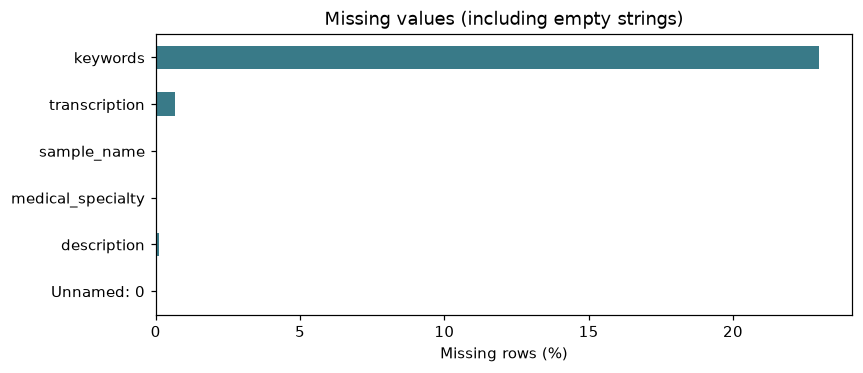

In [2]:
missing = pd.DataFrame({
    "missing_count": [int(blank_mask(raw[c]).sum()) for c in raw.columns],
}, index=raw.columns.copy())
missing["missing_percent"] = missing.missing_count / len(raw) * 100
missing.index.name = "column"
display(missing.round(3))
fig, ax = plt.subplots(figsize=(8, 3.5))
missing.missing_percent.plot.barh(ax=ax, color="#397A88")
ax.set(xlabel="Missing rows (%)", ylabel="", title="Missing values (including empty strings)")
fig.tight_layout()
display(fig)
plt.close(fig)


## Duplicate rows and transcriptions

A unique exported index does not imply a unique medical report. We check whole rows, rows without the index, exact nonempty text, and text normalized only for duplicate detection (case, punctuation, whitespace). Counts are repeated rows **beyond the first**, excluding empty transcriptions. Original text is preserved in selected outputs.


In [3]:
nonempty_mask = ~blank_mask(raw.transcription)
nonempty_text = raw.loc[nonempty_mask, "transcription"]
normalized_text = nonempty_text.map(normalize_text)
source_fields = ["description", "medical_specialty", "sample_name", "transcription", "keywords"]
duplicate_counts = pd.Series({
    "duplicate full rows": int(raw.duplicated().sum()),
    "duplicate rows without index": int(raw[source_fields].duplicated().sum()),
    "exact repeated nonempty transcriptions": int(nonempty_text.duplicated().sum()),
    "normalized repeated nonempty transcriptions": int(normalized_text.duplicated().sum()),
    "distinct exact nonempty transcriptions": int(nonempty_text.nunique()),
    "distinct normalized nonempty transcriptions": int(normalized_text.nunique()),
}, name="count")
display(duplicate_counts.to_frame())
# Show source-row groups and labels, without printing entire repeated notes.
duplicate_groups = raw.loc[nonempty_mask, ["medical_specialty", "sample_name"]].copy()
duplicate_groups["source_row_id"] = duplicate_groups.index
duplicate_groups["normalized"] = normalized_text
group_summary = duplicate_groups.groupby("normalized").agg(
    copies=("source_row_id", "size"),
    source_row_ids=("source_row_id", list),
    specialties=("medical_specialty", lambda s: sorted(set(s.str.strip()))),
).sort_values("copies", ascending=False)
display(group_summary.head(8).reset_index(drop=True))


,count
duplicate full rows,0
duplicate rows without index,0
exact repeated nonempty transcriptions,2609
normalized repeated nonempty transcriptions,2611
distinct exact nonempty transcriptions,2357
distinct normalized nonempty transcriptions,2355


,copies,source_row_ids,specialties
0,6,"[24, 2053, 2206, 2454, 2488, 4095]","[Consult - History and Phy., Office Notes, Ort..."
1,5,"[568, 1617, 1973, 2166, 2855]","[Neurology, Orthopedic, Pain Management, Radio..."
2,4,"[1920, 2801, 3131, 4266]","[Consult - History and Phy., Hematology - Onco..."
3,4,"[1582, 2154, 2826, 4604]","[Chiropractic, Neurology, Orthopedic, Radiology]"
4,4,"[1434, 3445, 3982, 4871]","[Cardiovascular / Pulmonary, Discharge Summary..."
5,4,"[1911, 2474, 3244, 4230]","[Consult - History and Phy., General Medicine,..."
6,4,"[1352, 3269, 3490, 3823]","[Emergency Room Reports, Gastroenterology, Gen..."
7,4,"[117, 3016, 3832, 4333]","[Consult - History and Phy., Emergency Room Re..."


## Medical specialty distribution

These are source labels, which mix specialties and report formats. All 40 labels are shown. Original counts include duplicate reports, so they describe the downloaded table rather than independent patients or unique reports.


Number of specialty labels: 40


,rows,percent
medical_specialty,,
Surgery,1103,22.06
Consult - History and Phy.,516,10.32
Cardiovascular / Pulmonary,372,7.44
Orthopedic,355,7.10
Radiology,273,5.46
General Medicine,259,5.18
Gastroenterology,230,4.60
Neurology,223,4.46
SOAP / Chart / Progress Notes,166,3.32


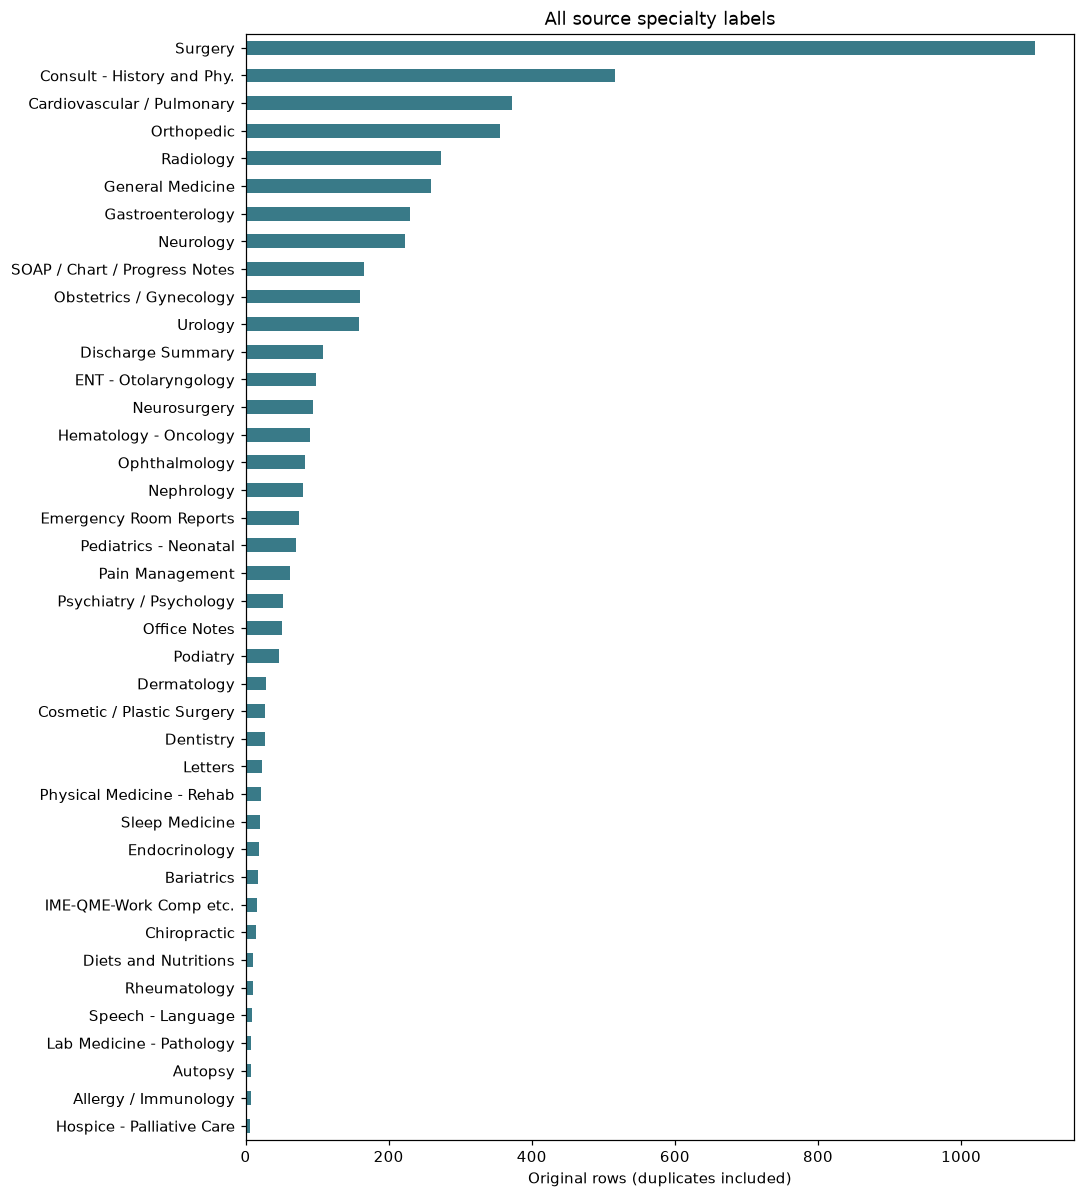

In [4]:
specialty_counts = raw.medical_specialty.str.strip().replace("", "(missing)").value_counts()
print("Number of specialty labels:", len(specialty_counts))
specialty_table = specialty_counts.rename_axis("medical_specialty").to_frame("rows")
specialty_table["percent"] = specialty_table.rows / len(raw) * 100
display(specialty_table.round(2))
fig, ax = plt.subplots(figsize=(10, 11))
specialty_counts.sort_values().plot.barh(ax=ax, color="#397A88")
ax.set(xlabel="Original rows (duplicates included)", ylabel="", title="All source specialty labels")
fig.tight_layout()
display(fig)
plt.close(fig)


## Transcription length and obvious unusable rows

Word count means whitespace-delimited tokens, consistently throughout this analysis. Comma-separated headings in MTSamples can join words, so this is a reproducible length proxy rather than linguistic tokenization. Statistics exclude blank notes, with all-row statistics also shown for transparency. The cleaning minimum is 40 words; short/medium/long boundaries will instead come from the cleaned pool's actual tertiles.

- **Tertiles:** Dividing the cleaned reports into three roughly equal groups by word count: short, medium, and long. The boundaries are calculated later in the notebook.

,nonempty_transcriptions,all_rows_including_empty
count,4966.00,4999.00
mean,465.45,462.38
std,316.39,317.59
min,1.00,0.00
25%,241.00,239.00
50%,398.00,397.00
75%,615.00,614.00
max,3029.00,3029.00


Nonempty notes below 40 words: 76


,source_row_id,sample_name,medical_specialty,word_count,text_preview
0,1379,Gen Med SOAP - 1,SOAP / Chart / Progress Notes,1,"SUBJECTIVE:,"
1,1525,Stress Test Dobutrex,Radiology,1,"INDICATIONS:,"
2,1949,Trigger Point Injection,Pain Management,1,"OPERATION:,"
3,1994,Epidural Blood Patch,Pain Management,1,"OPERATION:,"
4,3306,Gen Med SOAP - 1,General Medicine,1,"SUBJECTIVE:,"
5,4658,Stress Test Dobutrex,Cardiovascular / Pulmonary,1,"INDICATIONS:,"
6,24,Urology Consut - 1,Urology,2,"CHIEF COMPLAINT:,"
7,872,EGD with Dilation,Surgery,2,"INDICATION: ,"
8,2206,Hip Pain,Orthopedic,2,"CHIEF COMPLAINT:,"
9,2488,Hip Pain,Office Notes,2,"CHIEF COMPLAINT:,"


EDAs\mtsamples_eda.ipynb:cell-9:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.


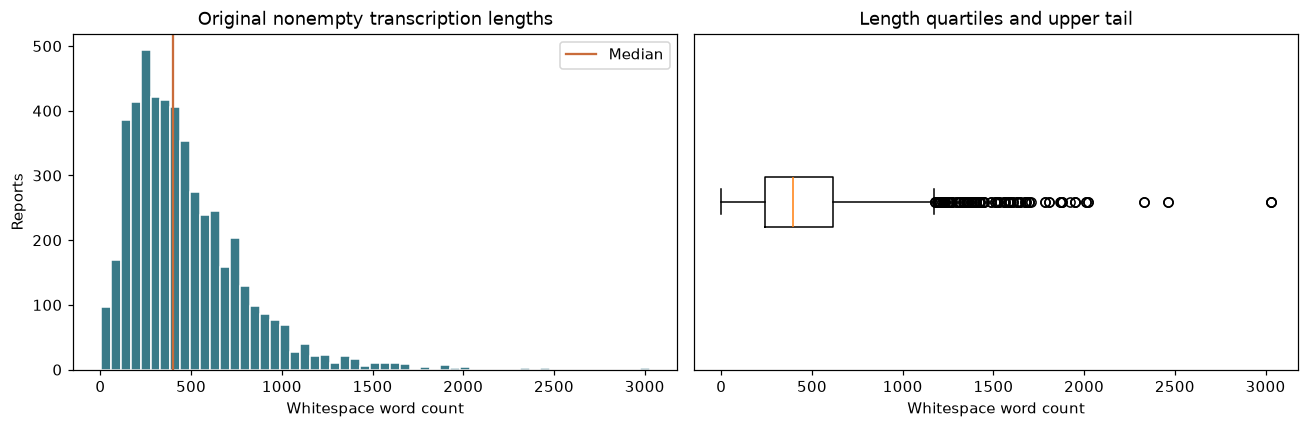

In [5]:
raw_words = word_counts(raw)
word_summary = pd.DataFrame({
    "nonempty_transcriptions": raw_words[nonempty_mask].describe(percentiles=[.25, .5, .75]),
    "all_rows_including_empty": raw_words.describe(percentiles=[.25, .5, .75]),
})
display(word_summary.round(2))
print("Nonempty notes below 40 words:", int(((raw_words > 0) & (raw_words < MIN_WORDS)).sum()))
shortest_ids = raw_words[nonempty_mask].nsmallest(15).index
shortest = raw.loc[shortest_ids, ["sample_name", "medical_specialty"]].copy()
shortest.insert(0, "source_row_id", shortest.index)
shortest["word_count"] = raw_words.loc[shortest_ids]
shortest["text_preview"] = raw.loc[shortest_ids, "transcription"].str.slice(0, 160)
display(shortest.reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_words[nonempty_mask], bins=55, color="#397A88", edgecolor="white")
axes[0].axvline(raw_words[nonempty_mask].median(), color="#C96C3A", label="Median")
axes[0].set(xlabel="Whitespace word count", ylabel="Reports", title="Original nonempty transcription lengths")
axes[0].legend()
axes[1].boxplot(raw_words[nonempty_mask], vert=False)
axes[1].set(xlabel="Whitespace word count", yticks=[], title="Length quartiles and upper tail")
fig.tight_layout()
display(fig)
plt.close(fig)


### How to read the table and plots

- **Second table:** These are the 15 shortest reports that contain any text. It helps us spot entries that are only a heading or a few words and may be unusable. Your notebook viewer may put scrollbars around the output to fit it on screen; that is normal.
- **`text_preview`:** The first 160 characters of each transcription, so you can see what the short entry looks like without showing the full report.
- **Right-hand plot:** This box plot shows how report lengths vary. The box covers the middle half of reports, the line inside is the median, and points far to the right are unusually long reports.

## Candidate cleaning and near-duplicate screening

Sequential exclusions: missing transcription; fewer than 40 words; fewer than 15 distinct alphabetic tokens; less than 50% alphabetic non-whitespace characters or replacement/control characters; a final empty field/heading ending in a colon; obvious mid-phrase endings; explicit template/opening-fragment titles; normalized duplicates; near-duplicates.

An absent content keyword is **not** a reason to discard a meaningful diagnostic report. Optional missing metadata remains blank. Short-note and truncation rules are conservative suitability checks, not clinical judgments.

Near-duplicate detection compares sets of consecutive five-word shingles, requiring Jaccard >= 0.85 and a token-length ratio >= 0.8. Connected components keep at most one representative. Prefer an existing target-specialty label, then the less frequent specialty in the usable pool, then the lowest source row ID. This handles reports repeated under several source labels without inventing a label.

The implementation, exact regexes, and deterministic rules live in the adjacent sampler. This cell runs them on the original dataframe, creating a separate candidate dataframe and a row-level audit in memory.

***Jaccard** similarity measures how much two sets overlap


In [6]:
candidates, audit, cleaning = clean_candidates(raw)
print(f"Cleaned candidate pool: {len(candidates):,} reports")
print("Unique normalized reports before near-deduplication:", cleaning["normalized_unique_before_near_dedup"])
print("Qualifying near-duplicate pairs:", len(cleaning["near_duplicate_pairs"]))
exclusions = audit.loc[audit.exclusion_reason.ne(""), "exclusion_reason"].value_counts()
display(exclusions.rename_axis("sequential exclusion reason").to_frame("rows"))
assert len(candidates) + int(exclusions.sum()) == len(raw)
assert not candidates.transcription.map(normalize_text).duplicated().any()
# Illustrate quality exclusions using source IDs, titles, and endings.
quality = audit.loc[audit.exclusion_reason.ne("") & ~audit.exclusion_reason.str.contains("duplicate")]
quality_examples = quality.groupby("exclusion_reason", sort=True).head(2).copy()
quality_examples["sample_name"] = quality_examples.source_row_id.map(raw.sample_name)
quality_examples["text_ending"] = quality_examples.source_row_id.map(raw.transcription).str.slice(-120)
display(quality_examples.drop(columns="retained_source_row_id").reset_index(drop=True))
display(pd.DataFrame(cleaning["near_duplicate_pairs"], columns=["source_row_a", "source_row_b", "five_shingle_jaccard"]))


Cleaned candidate pool: 2,218 reports
Unique normalized reports before near-deduplication: 2219
Qualifying near-duplicate pairs: 1


,rows
sequential exclusion reason,
normalized duplicate transcription,2436
ends with an empty heading/field (apparent truncation),134
explicit template or standalone opening fragment,96
fewer than 40 whitespace words (too little text for this subset),76
missing transcription,33
ends mid-phrase (apparent truncation),5
near-duplicate transcription,1


,source_row_id,exclusion_reason,sample_name,text_ending
0,24,fewer than 40 whitespace words (too little tex...,Urology Consut - 1,"CHIEF COMPLAINT:,"
1,84,explicit template or standalone opening fragment,Meatotomy Template,applied. The procedure was terminated. The p...
2,89,explicit template or standalone opening fragment,Meatoplasty Template,wrapped around the penis. There was good hem...
3,97,missing transcription,Inguinal orchiopexy,
4,116,missing transcription,Hydrocele Repair,
5,142,fewer than 40 whitespace words (too little tex...,Cystourethroscopy & Retrograde Pyelogram,"PREOPERATIVE DIAGNOSES:,1. Recurrent bladder ..."
6,177,ends mid-phrase (apparent truncation),YAG Laser Capsulotomy - 1,en positioned and applications of laser energy...
7,281,ends mid-phrase (apparent truncation),Thoracotomy & Esophageal Exploration,"c content.,Gastrostomy tube study, with interp..."
8,1133,ends with an empty heading/field (apparent tru...,Bronchoscopy - 7,"25 mg), p.o. 1 hour before the procedure.,2. ..."
9,1234,ends with an empty heading/field (apparent tru...,Anterior Cervical Discectomy & Interbody Fusi...,lization by Uniplate construction at C5-C6 (22...


,source_row_a,source_row_b,five_shingle_jaccard
0,153,168,0.921986


## Historical mixed-length sampling design: specialty, length, structure, content, and complexity

This is a purposive diversity sample, not a frequency-weighted random sample. Fifteen source categories cover general medicine, organ systems, acute care, surgery, and report formats. Five receive 4 reports and ten receive 3; no category exceeds 8%.

Length boundaries are tertiles over **all cleaned candidates**, with targets of 17 short, 17 medium, and 16 long. A deterministic allocation satisfies both specialty and length quotas, including each available length in each specialty. It fails explicitly if those constraints cannot be met.

Within each specialty/length cell, a greedy score favors less represented content cues, structures, and textual-complexity groups. The score is `4/(1+complexity_count) + 3/(1+structure_count) + sum(1/(1+content_cue_count))`. Cells with fewer candidates per requested slot come first. Seed 42 breaks tied scores, with ranks assigned in source-row order.

Text complexity averages candidate-pool percentile ranks of distinct words with at least 9 letters, numeric-token count, section-heading count, and distinct content-cue count, then uses tertiles. Structure is a title/heading-based indicator. These are sampling aids, **not medical severity, clinical fact extraction, or gold annotations**. Content cues can match negated statements; the exact patterns are displayed below.


In [7]:
q_short, q_medium = cleaning["length_tertiles"]
print(f"Short <= {q_short:g}; medium > {q_short:g} and <= {q_medium:g}; long > {q_medium:g} words")
print("Complexity tertiles:", cleaning["complexity_tertiles"])
display(pd.Series(SPECIALTY_TARGETS, name="target_reports").rename_axis("specialty").to_frame())
display(pd.crosstab(candidates.medical_specialty, candidates.length_category)
        .reindex(index=list(SPECIALTY_TARGETS), columns=list(LENGTH_TARGETS), fill_value=0))
display(pd.Series(CONTENT_PATTERNS, name="regex_presence_cue").rename_axis("sampling indicator").to_frame())
selected = select_reports(candidates)
validate_selection(selected, raw)
print("Selected and validated:", len(selected))
display(selected[["source_row_id", "medical_specialty", "sample_name", "word_count", "length_category", "selection_reason"]])


Short <= 294; medium > 294 and <= 528; long > 528 words
Complexity tertiles: [0.3791704238052299, 0.6262962128043282]


,target_reports
specialty,
General Medicine,4
Cardiovascular / Pulmonary,4
Neurology,4
Gastroenterology,3
Orthopedic,3
Urology,3
Allergy / Immunology,3
Endocrinology,3
Hematology - Oncology,3


length_category,short,medium,long
medical_specialty,,,
General Medicine,22,38,47
Cardiovascular / Pulmonary,72,77,91
Neurology,54,76,67
Gastroenterology,91,62,27
Orthopedic,34,79,143
Urology,57,46,37
Allergy / Immunology,3,1,3
Endocrinology,1,6,11
Hematology - Oncology,28,23,20


,regex_presence_cue
sampling indicator,
diagnoses,\b(?:diagnos\w*|impression|assessment)\b
symptoms,\b(?:symptoms?|complaints?|pain|dyspnea|nausea...
medications,\b(?:medications?|medicines?|prescri\w*|\d+\s*...
allergies,\b(?:allerg\w*|nkda)\b
laboratory values,\b(?:laboratory|labs?|hemoglobin|hematocrit|cr...
vital signs,\b(?:vital signs|blood pressure|pulse|heart ra...
procedures,\b(?:procedures?|catheter\w*|biopsy|endoscopy|...
imaging,\b(?:imaging|x[ -]?rays?|mri|ct|ultrasound|rad...
past history,\b(?:past medical|past surgical|family history...


Selected and validated: 50


,source_row_id,medical_specialty,sample_name,word_count,length_category,selection_reason
0,4995,Allergy / Immunology,Kawasaki Disease - Discharge Summary,270,short,Allergy / Immunology; short; discharge summary...
1,4997,Allergy / Immunology,Asthma in a 5-year-old,390,medium,Allergy / Immunology; medium; other narrative/...
2,4996,Allergy / Immunology,Followup on Asthma,708,long,Allergy / Immunology; long; follow-up/progress...
3,4874,Cardiovascular / Pulmonary,Chest Pain - Office Note,144,short,Cardiovascular / Pulmonary; short; follow-up/p...
4,4690,Cardiovascular / Pulmonary,Pulmonary Consultation - 2,244,short,Cardiovascular / Pulmonary; short; consultatio...
5,4787,Cardiovascular / Pulmonary,Heart Catheterization - 2,477,medium,Cardiovascular / Pulmonary; medium; procedure/...
6,4965,Cardiovascular / Pulmonary,Atrial Fibrillation - Consult,1143,long,Cardiovascular / Pulmonary; long; consultation...
7,4447,Consult - History and Phy.,Ear Pain - Drainage,241,short,Consult - History and Phy.; short; other narra...
8,4345,Consult - History and Phy.,H&P - Infant with fever,418,medium,Consult - History and Phy.; medium; history an...
9,4427,Consult - History and Phy.,Erythema Nodosum - Consult,2332,long,Consult - History and Phy.; long; consultation...


## Historical mixed-length specialty and length distributions


,selected
specialty,
Allergy / Immunology,3
Cardiovascular / Pulmonary,4
Consult - History and Phy.,3
Discharge Summary,4
Emergency Room Reports,4
Endocrinology,3
Gastroenterology,3
General Medicine,4
Hematology - Oncology,3


,selected
length,
short,17
medium,17
long,16


,selected_words
count,50.00
mean,543.68
std,460.30
min,144.00
25%,259.25
50%,422.00
75%,566.75
max,2460.00


Shortest: source row 4874; 144 words; Chest Pain - Office Note
Longest: source row 2796; 2460 words; Neurologic Consultation - 5


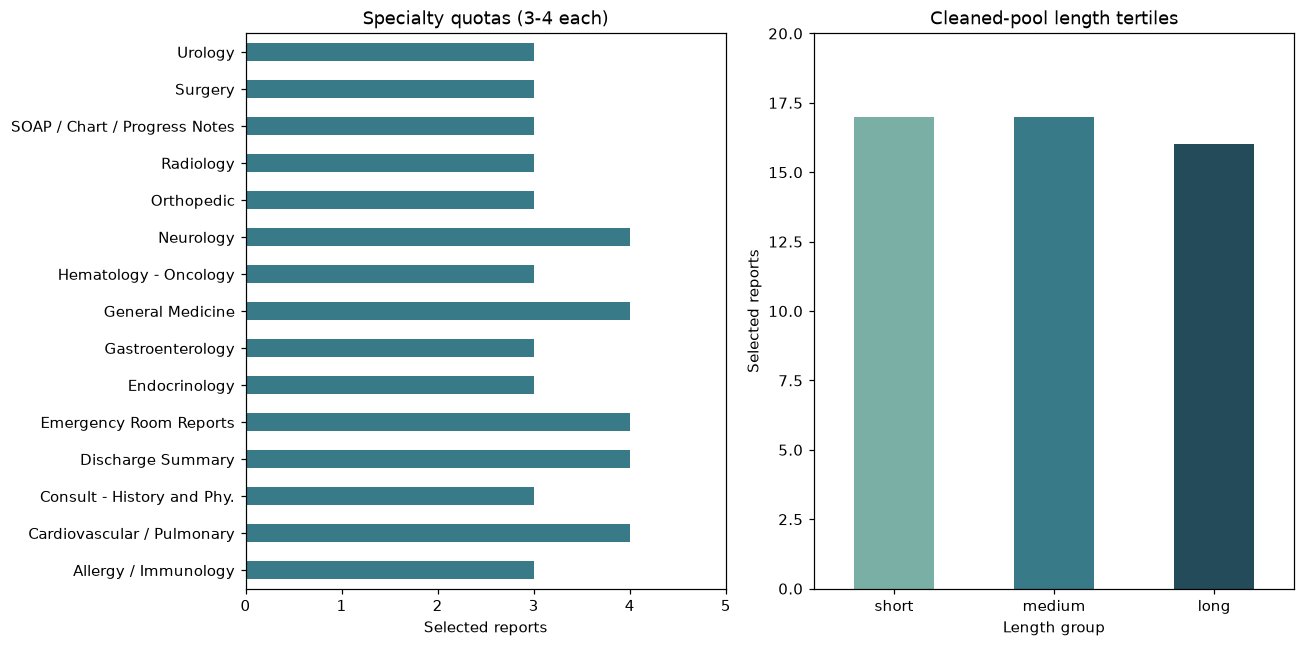

In [8]:
selected_specialties = selected.medical_specialty.value_counts().sort_index()
selected_lengths = selected.length_category.value_counts().reindex(list(LENGTH_TARGETS))
display(selected_specialties.rename_axis("specialty").to_frame("selected"))
display(selected_lengths.rename_axis("length").to_frame("selected"))
display(selected.word_count.describe().round(2).to_frame("selected_words"))
for label, idx in [("Shortest", selected.word_count.idxmin()), ("Longest", selected.word_count.idxmax())]:
    row = selected.loc[idx]
    print(f"{label}: source row {row.source_row_id}; {row.word_count} words; {row.sample_name.strip()}")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
selected_specialties.plot.barh(ax=axes[0], color="#397A88")
axes[0].set(xlabel="Selected reports", ylabel="", title="Specialty quotas (3-4 each)", xlim=(0, 5))
selected_lengths.plot.bar(ax=axes[1], color=["#79AFA4", "#397A88", "#244B5A"], rot=0)
axes[1].set(ylabel="Selected reports", xlabel="Length group", title="Cleaned-pool length tertiles", ylim=(0, 20))
fig.tight_layout()
display(fig)
plt.close(fig)


## Content, structure, and textual complexity coverage

Counts overlap across content cues. They show lexical evidence for sampling coverage, not verified clinical assertions. The patient source text, including negations, units, placeholders, and original punctuation, remains untouched.


,matching_reports
content cue,
allergies,21
assessment/plan,27
diagnoses,49
follow-up,31
imaging,32
laboratory values,21
medications,36
past history,34
procedures,30


,reports
structure indicator,
procedure/operative,9
consultation,8
other narrative/sectioned,7
SOAP-style,6
diagnostic report,6
follow-up/progress,5
history and physical,5
discharge summary,4


,reports
text complexity,
lower,13
middle,17
higher,20


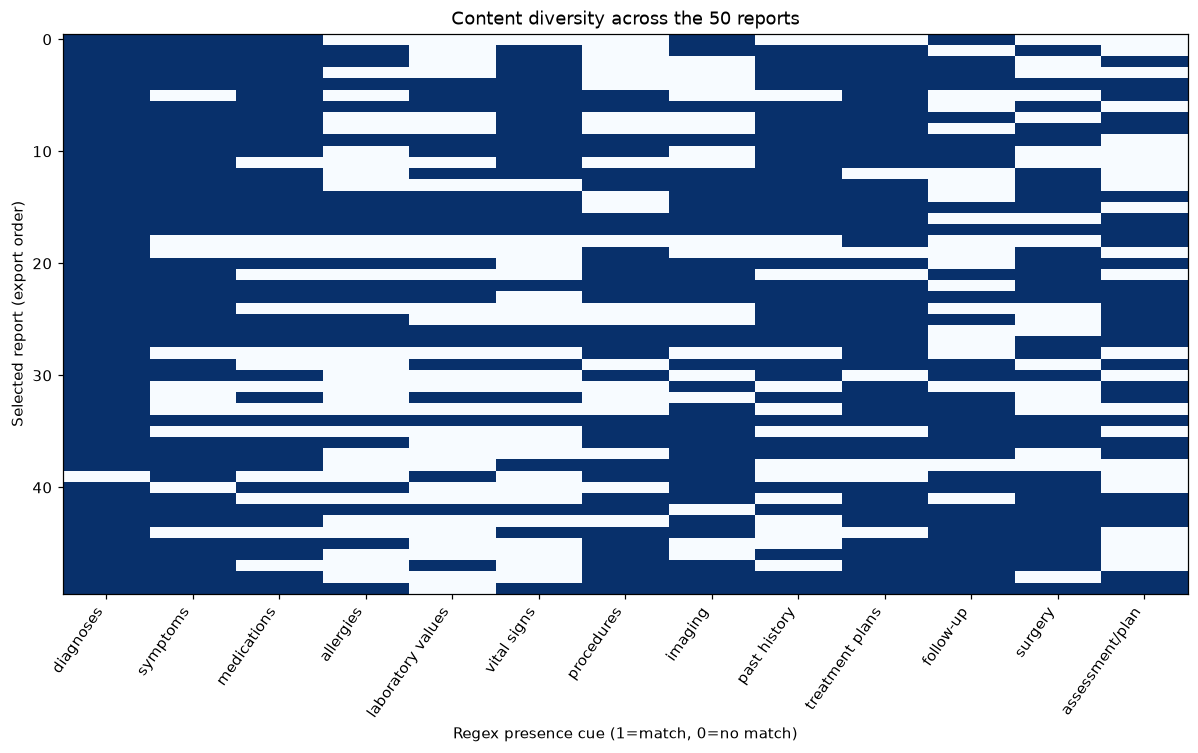

In [9]:
content_counts = Counter(cue for text in selected.transcription for cue in content_indicators(text))
display(pd.Series(content_counts).sort_index().rename_axis("content cue").to_frame("matching_reports"))
display(selected.structure_indicator.value_counts().rename_axis("structure indicator").to_frame("reports"))
display(selected.text_complexity_category.value_counts().reindex(["lower", "middle", "higher"])
        .rename_axis("text complexity").to_frame("reports"))
indicator_matrix = np.array([[int(cue in content_indicators(t)) for cue in CONTENT_PATTERNS] for t in selected.transcription])
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(indicator_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CONTENT_PATTERNS)), list(CONTENT_PATTERNS), rotation=55, ha="right")
ax.set(xlabel="Regex presence cue (1=match, 0=no match)", ylabel="Selected report (export order)", title="Content diversity across the 50 reports")
fig.tight_layout()
display(fig)
plt.close(fig)


## Historical selection reproducibility

The original mixed-length selection is preserved in memory as `selected`. Its rules and saved analysis remain here for comparison. The next cell checks its selected IDs against the original committed manifest. The old CSV/Excel outputs are preserved in Git history (commit `5d415c7`), while the current export paths contain the medium-focused set with two documented Allergy length exceptions.

To reproduce the old exports separately, use `python EDAs/mtsamples_sampling.py --profile mixed --output <another-directory>`. The default command now produces the medium-focused set. This notebook does not overwrite any exports.


In [10]:
validate_selection(selected, raw)
pd.testing.assert_frame_equal(selected, select_reports(candidates))
legacy_selected_ids = [4995, 4997, 4996, 4874, 4690, 4787, 4965, 4447, 4345, 4427, 3963, 3962, 3911, 3966, 3864, 3838, 3818, 3859, 3800, 3798, 3797, 3604, 3472, 3525, 3362, 3375, 3319, 3287, 3150, 3127, 3119, 2920, 2868, 2964, 2796, 2270, 2365, 2078, 1618, 1663, 1639, 1307, 1396, 1392, 783, 422, 768, 113, 137, 130]
assert selected.source_row_id.tolist() == legacy_selected_ids
assert hashlib.sha256(SOURCE.read_bytes()).hexdigest() == source_hash_before
print("Original mixed-length selection reproduced: all 50 IDs match the historical manifest.")
print("The active CSV/Excel files are checked against the medium-focused selection below.")


Original mixed-length selection reproduced: all 50 IDs match the historical manifest.
The active CSV/Excel files are checked against the medium-focused selection below.


## Historical mixed-length EDA summary

- **Dataset:** 4,999 rows, 6 columns, and 40 specialty labels. There are 4,966 nonempty transcriptions. This saved summary describes source SHA-256 `a92cb78569f460606661ee7da50c92305b60d0fac2be4b06c8d2de0f234612d4`; recompute and update it if the source or selection rules change.
- **Missing values:** transcription 33 (0.660%); description 6 (0.120%); keywords 1,149 (22.985%); specialty and sample name 0. Missing optional metadata is retained rather than invented.
- **Duplicates and quality:** 0 duplicate full rows, but 2,609 repeated nonempty transcriptions beyond the first (2,611 after normalization). After sequential quality checks, 2,436 normalized duplicates and 1 near-duplicate are removed. Quality exclusions are 33 missing notes, 76 nonempty notes below 40 words, 134 notes ending with empty headings/fields, 5 mid-phrase endings, and 96 explicit templates/opening fragments. **2,218 candidates remain.** These heuristic exclusions do not establish clinical correctness or detect every incomplete note.
- **Specialties:** Surgery has 1,103 rows (22.06%) and Consult - History and Phy. has 516 (10.32%); the smallest category has 6. Duplicate reports cross specialty labels. This motivated deduplication before purposive sampling and a cap of 4 selected reports per category.
- **Raw nonempty lengths:** min 1, Q1 241, median 398, mean 465.45, Q3 615, max 3,029 words. The distribution has a long upper tail. Cleaned-pool tertiles are **294 and 528 words**, defining short/medium/long without arbitrary length-bin thresholds.
- **Selected subset:** 50 unchanged reports spanning 15 source categories, with **17 short, 17 medium, and 16 long**. Mean 543.68, median 422, range 144-2460 words. There are 8 structure indicators and 13/17/20 reports in lower/middle/higher textual-complexity groups. Every requested content cue is represented in at least 3 reports.
- **Selection implications:** specialty and length quotas provide primary coverage; deterministic greedy diversity scoring with seed 42 breaks ties within groups. This set intentionally does not mirror source prevalence. Regex cues and complexity are sampling aids, not clinical annotations. It is a **selected evaluation subset, not a cleaned replacement dataset**, and is proposed for team review and freezing before any headline evaluation. No model outputs or annotations were created.


## Active selection: 50-report medium-focused subset

The first baseline now primarily uses medium-length reports, with two documented Allergy/Immunology length exceptions. The earlier mixed-length work above is retained for comparison. The same CSV/Excel filenames now hold this single active set; the old files can be recovered from Git history.

**Medium means 295-528 whitespace words for this source snapshot**, using the original cleaned-pool tertiles (more than 294 and at most 528). We keep those boundaries fixed rather than dividing the medium group into thirds again. Medium length does not mean medium text complexity: we still include lower-, middle-, and higher-complexity reports.

We start with the original 2,218 cleaned, deduplicated reports, of which 740 are medium-length. An extra screen avoids explicit transcription blanks (two or more underscores or bracketed inaudible/unintelligible markers). These may hide missing clinical text; this conservative rule can also remove harmless redactions. No report text is rewritten. The final set contains 48 medium reports and two complete, gap-free allergy reports outside that range.


In [11]:
from mtsamples_medium_sampling import (
    medium_pool, medium_targets, select_medium_reports,
    validate_medium_selection, selection_audit,
)
medium_candidates = candidates.loc[candidates.length_category.eq("medium")]
screened_medium = medium_pool(candidates)
targets_medium = medium_targets(candidates)
display(pd.Series({
    "Original rows": len(raw),
    "After original cleaning": len(candidates),
    "Medium-length candidates": len(medium_candidates),
    "After transcription-gap screen": len(screened_medium),
    "Within the 15 target specialties": int(screened_medium.medical_specialty.isin(SPECIALTY_TARGETS).sum()),
    "To select": 50,
}, name="reports").to_frame())
quota_medium = pd.DataFrame({
    "original_target": pd.Series(SPECIALTY_TARGETS),
    "medium_available": screened_medium.medical_specialty.value_counts(),
    "documented_length_exceptions": pd.Series({"Allergy / Immunology": 2}),
    "selected_target": pd.Series(targets_medium),
}).reindex(list(SPECIALTY_TARGETS)).fillna(0).astype(int)
quota_medium.index.name = "specialty"
display(quota_medium)


,reports
Original rows,4999
After original cleaning,2218
Medium-length candidates,740
After transcription-gap screen,679
Within the 15 target specialties,653
To select,50


,original_target,medium_available,documented_length_exceptions,selected_target
specialty,,,,
General Medicine,4,37,0,4
Cardiovascular / Pulmonary,4,67,0,4
Neurology,4,75,0,4
Gastroenterology,3,53,0,3
Orthopedic,3,70,0,3
Urology,3,39,0,3
Allergy / Immunology,3,1,2,3
Endocrinology,3,5,0,3
Hematology - Oncology,3,22,0,3


### Choosing a useful range of medium reports

We preserve all 15 target specialty labels and restore the original quotas. Allergy/Immunology has only one eligible medium report, so we make two explicit, gap-free source exceptions: **Allergic Rhinitis** (source row 0, 204 words, short) and **Allergy Evaluation Consult** (source row 4998, 638 words, long). These are direct allergy cases and place one shorter and one longer report around the existing 390-word medium asthma case. Surgery and Orthopedic each return to three reports, leaving 48 medium reports in the 50-report set. No specialty gets more than four reports.

Within each specialty, the sampler favors content cues, report structures, and complexity groups that are less represented so far. It uses the same diversity score as the earlier analysis and seed 42 for ties. The exact score and quota rule are documented in `data/curated_baseline/README.md`.

Here, "best" means usable source text plus broad coverage under these documented rules. It is not a ranking of clinical accuracy. Team review is still needed before freezing the set, and evaluation results will mainly describe medium-length reports, with two named exceptions.


In [12]:
medium_selected = select_medium_reports(candidates)
validate_medium_selection(medium_selected, raw, candidates)
pd.testing.assert_frame_equal(medium_selected, select_medium_reports(candidates))
print("Selected and validated:", len(medium_selected), "reports (48 medium, 2 Allergy length exceptions)")
with pd.option_context("display.max_rows", 60):
    display(medium_selected[["source_row_id", "medical_specialty", "sample_name", "word_count", "length_category",
                             "structure_indicator", "text_complexity_category"]])
medium_audit = selection_audit(audit, candidates, medium_selected)
display(medium_audit.selection_status.value_counts().rename_axis("selection status").to_frame("rows"))


Selected and validated: 50 reports (48 medium, 2 Allergy length exceptions)


,source_row_id,medical_specialty,sample_name,word_count,length_category,structure_indicator,text_complexity_category
0,0,Allergy / Immunology,Allergic Rhinitis,204,short,SOAP-style,lower
1,4997,Allergy / Immunology,Asthma in a 5-year-old,390,medium,other narrative/sectioned,higher
2,4998,Allergy / Immunology,Allergy Evaluation Consult,638,long,consultation,higher
3,4626,Cardiovascular / Pulmonary,Transesophageal Echocardiography Probe,341,medium,other narrative/sectioned,lower
4,4720,Cardiovascular / Pulmonary,Non-Q-wave Myocardial Infarction,458,medium,consultation,higher
5,4787,Cardiovascular / Pulmonary,Heart Catheterization - 2,477,medium,procedure/operative,middle
6,4976,Cardiovascular / Pulmonary,Abnormal Echocardiogram,482,medium,consultation,higher
7,4457,Consult - History and Phy.,Dietary Consultation - 1,295,medium,SOAP-style,lower
8,4345,Consult - History and Phy.,H&P - Infant with fever,418,medium,history and physical,middle
9,4218,Consult - History and Phy.,OB/GYN - H&P,490,medium,history and physical,higher


,rows
selection status,
excluded during cleaning,2781
cleaned report outside medium length range,1476
eligible medium report not selected,605
medium report with explicit transcription gap,61
selected,48
medium report outside target specialties,26
selected Allergy length exception,2


,selected words
count,50.00
mean,410.24
std,82.68
min,204.00
25%,346.50
50%,408.50
75%,480.75
max,638.00


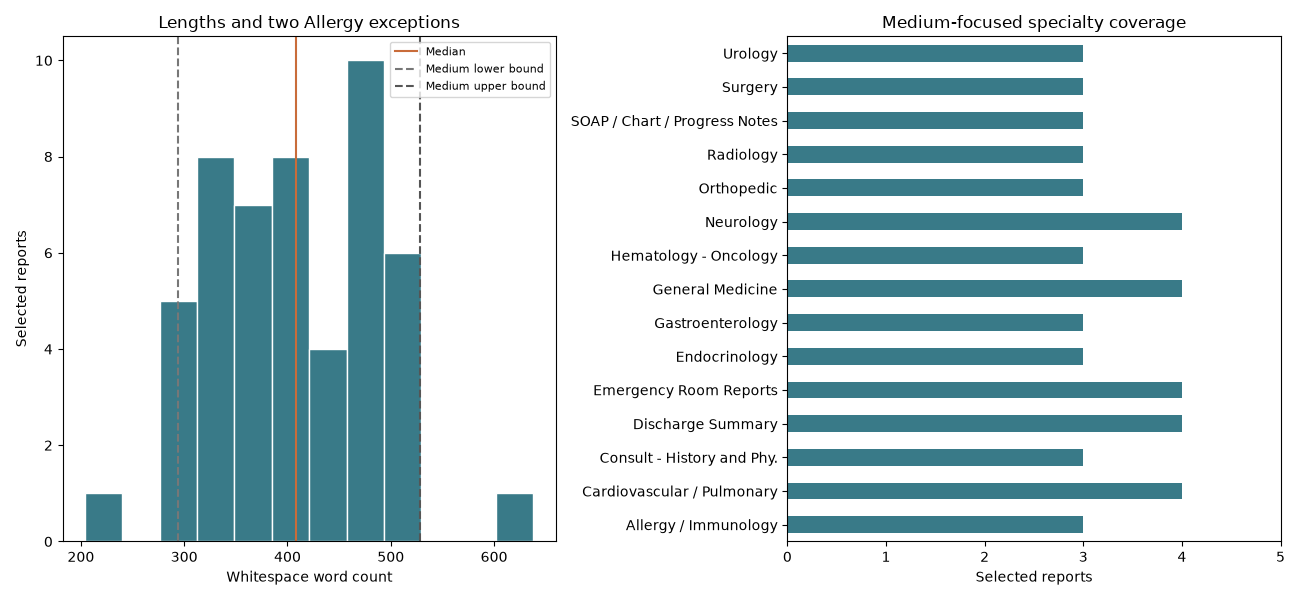

,matching reports
content cue,
allergies,24
assessment/plan,25
diagnoses,47
follow-up,23
imaging,30
laboratory values,18
medications,33
past history,33
procedures,23


,reports
structure,
other narrative/sectioned,8
consultation,8
procedure/operative,8
history and physical,7
SOAP-style,5
discharge summary,5
diagnostic report,5
follow-up/progress,4


,reports
text complexity,
lower,13
middle,16
higher,21


In [13]:
display(medium_selected.word_count.describe().round(2).to_frame("selected words"))
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].hist(medium_selected.word_count, bins=12, color="#397A88", edgecolor="white")
axes[0].axvline(medium_selected.word_count.median(), color="#C96C3A", label="Median")
axes[0].set(xlabel="Whitespace word count", ylabel="Selected reports", title="Lengths and two Allergy exceptions")
axes[0].axvline(294, color="#777777", linestyle="--", label="Medium lower bound")
axes[0].axvline(528, color="#555555", linestyle="--", label="Medium upper bound")
axes[0].legend(fontsize=8)
medium_selected.medical_specialty.value_counts().sort_index().plot.barh(ax=axes[1], color="#397A88")
axes[1].set(xlabel="Selected reports", ylabel="", title="Medium-focused specialty coverage", xlim=(0, 5))
fig.tight_layout()
display(fig)
plt.close(fig)
medium_cues = Counter(cue for text in medium_selected.transcription for cue in content_indicators(text))
display(pd.Series(medium_cues).sort_index().rename_axis("content cue").to_frame("matching reports"))
display(medium_selected.structure_indicator.value_counts().rename_axis("structure").to_frame("reports"))
display(medium_selected.text_complexity_category.value_counts().reindex(["lower", "middle", "higher"])
        .rename_axis("text complexity").to_frame("reports"))


The left plot shows lengths of all 50 selected reports, including the short and long Allergy exceptions outside the dashed medium boundaries. The right plot shows how the 50 reports are spread across specialties. The tables underneath show the topics, report styles, and complexity levels covered. Content cues can overlap and can match negated statements.

Reports that were eligible but not selected are not failed or bad reports. They were left out because only 50 places were available. The audit distinguishes those cases from cleaning exclusions, reports outside the medium range, explicit transcription gaps, and the two selected length exceptions.


In [14]:
comparison = pd.DataFrame({
    "historical mixed set": selected.word_count.describe(),
    "active medium-focused set": medium_selected.word_count.describe(),
}).round(2)
display(comparison)
display(pd.DataFrame({
    "historical mixed set": selected.length_category.value_counts(),
    "active medium-focused set": medium_selected.length_category.value_counts(),
}).reindex(["short", "medium", "long"]).fillna(0).astype(int))
print("Reports shared by both selections:", len(set(selected.source_row_id) & set(medium_selected.source_row_id)))


,historical mixed set,active medium-focused set
count,50.00,50.00
mean,543.68,410.24
std,460.30,82.68
min,144.00,204.00
25%,259.25,346.50
50%,422.00,408.50
75%,566.75,480.75
max,2460.00,638.00


,historical mixed set,active medium-focused set
length_category,,
short,17,1
medium,17,48
long,16,1


Reports shared by both selections: 11


### Active export checks and next steps

The active files are `data/curated_baseline/mtsamples_curated_50.csv`, the matching Excel workbook, `candidate_audit.csv`, `selection_manifest.json`, and the README. These existing files are tracked in Git. The old mixed-length exports are retained in Git history, so there is only one visible exported set.

Regenerate the medium-focused set from the repository root with `python EDAs/mtsamples_sampling.py --profile medium`. The next cell checks source and code hashes, output hashes, selected IDs, and full CSV/Excel round trips. It does not write files.

This version is **v3-medium-with-allergy-exceptions-proposed**, awaiting review and freezing. The team should inspect full source reports, confirm suitability and coverage, and record any changes as a new version before running the baseline. No explanations or gold annotations have been generated here.


In [15]:
OUT = ROOT / "data/curated_baseline"
manifest = json.loads((OUT / "selection_manifest.json").read_text(encoding="utf-8"))
assert manifest["sampling_profile"] == "medium"
assert manifest["source_sha256"] == source_hash_before
assert hashlib.sha256(SOURCE.read_bytes()).hexdigest() == source_hash_before
assert manifest["selected_source_row_ids"] == medium_selected.source_row_id.tolist()
assert manifest["length_targets"] == {"medium": 48, "short": 1, "long": 1}
assert set(medium_selected.loc[medium_selected.length_category.ne("medium"), "source_row_id"]) == {0, 4998}
for filename, expected_hash in manifest["sampler_sha256"].items():
    assert hashlib.sha256((ROOT / "EDAs" / filename).read_bytes()).hexdigest() == expected_hash
for filename, expected_hash in manifest["output_sha256"].items():
    assert hashlib.sha256((OUT / filename).read_bytes()).hexdigest() == expected_hash
csv_back = pd.read_csv(OUT / "mtsamples_curated_50.csv", keep_default_na=False)
excel_back = pd.read_excel(OUT / "mtsamples_curated_50.xlsx", keep_default_na=False)
pd.testing.assert_frame_equal(medium_selected, csv_back, check_dtype=False)
pd.testing.assert_frame_equal(medium_selected, excel_back, check_dtype=False)
assert int(medium_audit.selected.sum()) == 50
print("Passed: 48 medium reports and 2 documented Allergy exceptions, original text, quotas, diversity, all 1,225 pair checks,")
print("repeat selection, historical selection preserved, source/code/output hashes, and CSV/Excel round trips.")


Passed: 48 medium reports and 2 documented Allergy exceptions, original text, quotas, diversity, all 1,225 pair checks,
repeat selection, historical selection preserved, source/code/output hashes, and CSV/Excel round trips.
